In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/US_Accidents_March23.csv")

In [3]:
df_experiment = df.copy()

In [4]:
df_experiment.shape

(7728394, 46)

In [5]:
df_experiment.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [6]:
df_experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

#### Show only null columns

In [7]:
missing_data = df_experiment.isnull().sum()[df_experiment.isnull().sum() > 0].sort_values(ascending=False)

print("--- Number of Null ---")
print(missing_data)

--- Number of Null ---
End_Lat                  3402762
End_Lng                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Sunrise_Sunset             23246
Civil_Twilight             23246
Nautical_Twilight          23246
Astronomical_Twilight      23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
City                         253
Description                    5
dtype: int64


In [8]:
missing_percent = (df_experiment.isnull().sum() / len(df_experiment)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("--- Percent of Null ---")
print(missing_df)

--- Percent of Null ---
End_Lat                  44.029355
End_Lng                  44.029355
Precipitation(in)        28.512858
Wind_Chill(F)            25.865904
Wind_Speed(mph)           7.391355
Visibility(mi)            2.291524
Wind_Direction            2.267043
Humidity(%)               2.253301
Weather_Condition         2.244438
Temperature(F)            2.120143
Pressure(in)              1.820288
Weather_Timestamp         1.555666
Sunrise_Sunset            0.300787
Civil_Twilight            0.300787
Nautical_Twilight         0.300787
Astronomical_Twilight     0.300787
Airport_Code              0.292881
Street                    0.140637
Timezone                  0.101030
Zipcode                   0.024779
City                      0.003274
Description               0.000065
dtype: float64


#### Drop the lines that contain null values ​​in those columns.

In [9]:
# Threshole 2 %
threshold_percent = 2.0
cols_to_dropna = missing_percent[(missing_percent > 0) & (missing_percent <= threshold_percent)].index.tolist()

print("--- Columns that contain less than 2% null ---")
print(cols_to_dropna)

--- Columns that contain less than 2% null ---
['Description', 'Street', 'City', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Pressure(in)', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [10]:
rows_before = df_experiment.shape[0]
df_experiment = df_experiment.dropna(subset=cols_to_dropna)
    
rows_after = df_experiment.shape[0]
rows_dropped = rows_before - rows_after
    
print(f"Number of rows delete: {rows_dropped:,} rows ({(rows_dropped/rows_before)*100:.2f}%)")
print(f"Number of rows remaining: {rows_after:,} rows")

Number of rows delete: 171,516 rows (2.22%)
Number of rows remaining: 7,556,878 rows


In [11]:
df_experiment["Start_Time"] = pd.to_datetime(df_experiment["Start_Time"], errors="coerce")
df_experiment["End_Time"] = pd.to_datetime(df_experiment["End_Time"], errors="coerce")

# Target Column
df_experiment["Duration(min)"] = (df_experiment["End_Time"] - df_experiment["Start_Time"]).dt.total_seconds() / 60.0

In [12]:
df_experiment.dropna(subset=["Start_Time", "End_Time", "Duration(min)"], inplace=True)

In [13]:
missing_percent = (df_experiment.isnull().sum() / len(df_experiment)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("--- Percent of Null ---")
print(missing_df)

--- Percent of Null ---
End_Lat              49.005912
End_Lng              49.005912
Precipitation(in)    30.071025
Wind_Chill(F)        27.098875
Wind_Speed(mph)       6.294778
Wind_Direction        0.615166
Visibility(mi)        0.600875
Weather_Condition     0.561409
Humidity(%)           0.542408
Temperature(F)        0.408931
dtype: float64


#### Check Skewness

In [14]:
def skewed(df):
    feature_cols = df.columns
    for col in feature_cols:
        if df[col].dtype in ["int64", "float64"]:
            skew = df[col].skew()
            direction = "right (positive)" if skew > 0 else "left (negative)"
            if abs(skew) > 1:
                print(f"[SKEWED]     {col:<30} skew = {skew:+.3f}  →  highly skewed {direction}")
            elif abs(skew) > 0.5:
                print(f"[MODERATE]   {col:<30} skew = {skew:+.3f}  →  moderately skewed {direction}")
            else:
                print(f"[NORMAL]     {col:<30} skew = {skew:+.3f}  →  approximately symmetric")

skewed(df_experiment)

[SKEWED]     Severity                       skew = +1.642  →  highly skewed right (positive)
[NORMAL]     Start_Lat                      skew = -0.056  →  approximately symmetric
[NORMAL]     Start_Lng                      skew = -0.481  →  approximately symmetric
[NORMAL]     End_Lat                        skew = -0.152  →  approximately symmetric
[NORMAL]     End_Lng                        skew = -0.333  →  approximately symmetric
[SKEWED]     Distance(mi)                   skew = +22.440  →  highly skewed right (positive)
[MODERATE]   Temperature(F)                 skew = -0.506  →  moderately skewed left (negative)
[MODERATE]   Wind_Chill(F)                  skew = -0.649  →  moderately skewed left (negative)
[NORMAL]     Humidity(%)                    skew = -0.405  →  approximately symmetric
[SKEWED]     Pressure(in)                   skew = -3.706  →  highly skewed left (negative)
[SKEWED]     Visibility(mi)                 skew = +2.495  →  highly skewed right (positive)
[SKEWE

#### Check Outlier

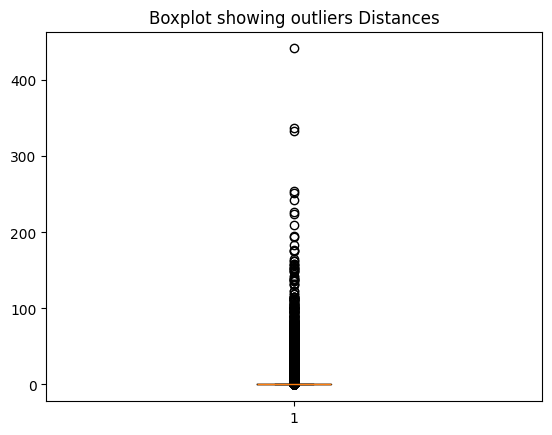

0.950     2.466
0.990     6.685
0.999    19.992
Name: Distance(mi), dtype: float64

In [15]:
# Distance
plt.boxplot(df_experiment["Distance(mi)"])
plt.title("Boxplot showing outliers Distances")
plt.show()

df_experiment["Distance(mi)"].quantile([0.95, 0.99, 0.999])

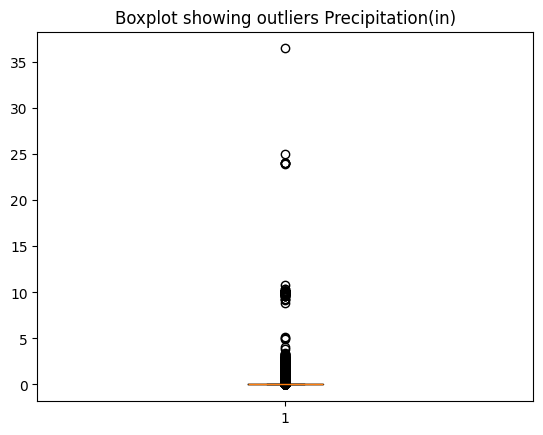

0.950    0.03
0.990    0.18
0.999    0.70
Name: Precipitation(in), dtype: float64

In [16]:
# Precipitation(in)
plt.boxplot(df_experiment["Precipitation(in)"].dropna())
plt.title("Boxplot showing outliers Precipitation(in)")
plt.show()

df_experiment["Precipitation(in)"].quantile([0.95, 0.99, 0.999])

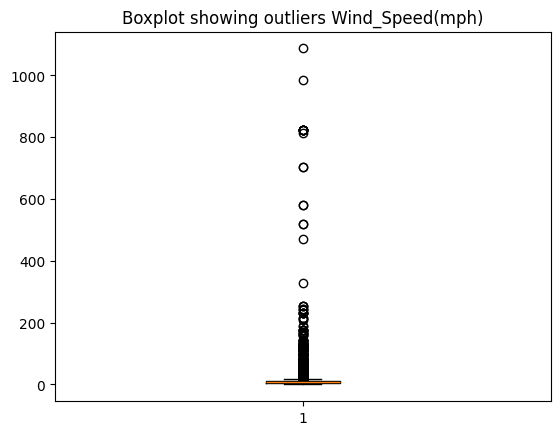

0.950    17.0
0.990    23.0
0.999    31.0
Name: Wind_Speed(mph), dtype: float64

In [17]:
# Wind Speed
plt.boxplot(df_experiment["Wind_Speed(mph)"].dropna())
plt.title("Boxplot showing outliers Wind_Speed(mph)")
plt.show()

df_experiment["Wind_Speed(mph)"].quantile([0.95, 0.99, 0.999])

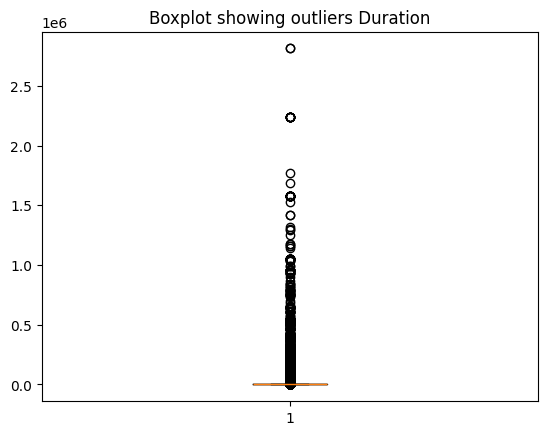

0.950     360.000000
0.990     779.483333
0.999    5718.389333
Name: Duration(min), dtype: float64

In [18]:
# Duration
plt.boxplot(df_experiment["Duration(min)"])
plt.title("Boxplot showing outliers Duration")
plt.show()

df_experiment["Duration(min)"].quantile([0.95, 0.99, 0.999])

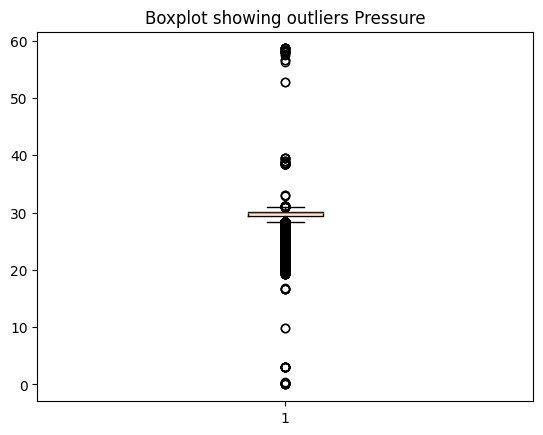

0.950    30.26
0.990    30.45
0.999    30.68
Name: Pressure(in), dtype: float64

In [19]:
# Pressure
plt.boxplot(df_experiment["Pressure(in)"].dropna())
plt.title("Boxplot showing outliers Pressure")
plt.show()

df_experiment["Pressure(in)"].quantile([0.95, 0.99, 0.999])

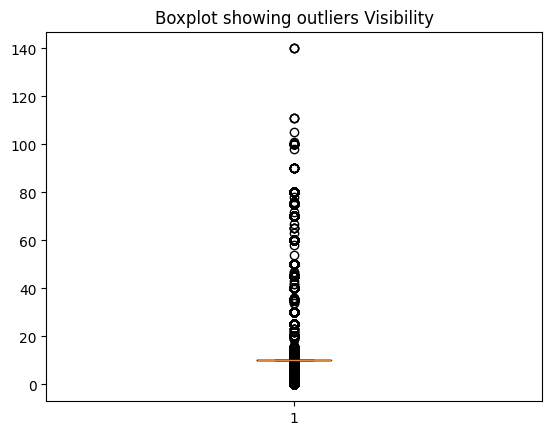

0.950    10.0
0.990    10.0
0.999    30.0
Name: Visibility(mi), dtype: float64

In [20]:
# Visibility
plt.boxplot(df_experiment["Visibility(mi)"].dropna())
plt.title("Boxplot showing outliers Visibility")
plt.show()

df_experiment["Visibility(mi)"].quantile([0.95, 0.99, 0.999])

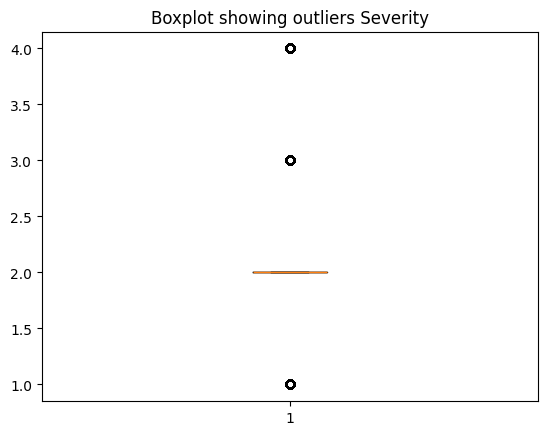

0.950    3.0
0.990    4.0
0.999    4.0
Name: Severity, dtype: float64

In [21]:
# Visibility
plt.boxplot(df_experiment["Severity"])
plt.title("Boxplot showing outliers Severity")
plt.show()

df_experiment["Severity"].quantile([0.95, 0.99, 0.999])

#### Manage excessively Outlier

In [22]:
def manage_outlier(df, outlier_columns):
    df_copy = df.copy()
    
    for col in outlier_columns:
        upper_limit_duration = df_copy[col].quantile(0.999)

        df_copy[col] = np.where(
            df_copy[col] > upper_limit_duration,
            upper_limit_duration,
            df_copy[col]
        )
    return df_copy

In [23]:
outlier_columns = ["Distance(mi)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)", "Duration(min)"]

df_outlier = manage_outlier(df_experiment, outlier_columns=outlier_columns)

In [24]:
len(df_outlier)

6836365

In [25]:
cols_to_drop = [
    "ID", "Source",
    "End_Lat", "End_Lng",
    "Timezone", "Airport_Code", "Weather_Timestamp",
    "End_Time"
]

df_basic_clean = df_outlier.drop(columns=cols_to_drop, errors="ignore")

array([[<Axes: title={'center': 'Severity'}>,
        <Axes: title={'center': 'Start_Time'}>,
        <Axes: title={'center': 'Start_Lat'}>,
        <Axes: title={'center': 'Start_Lng'}>],
       [<Axes: title={'center': 'Distance(mi)'}>,
        <Axes: title={'center': 'Temperature(F)'}>,
        <Axes: title={'center': 'Wind_Chill(F)'}>,
        <Axes: title={'center': 'Humidity(%)'}>],
       [<Axes: title={'center': 'Pressure(in)'}>,
        <Axes: title={'center': 'Visibility(mi)'}>,
        <Axes: title={'center': 'Wind_Speed(mph)'}>,
        <Axes: title={'center': 'Precipitation(in)'}>],
       [<Axes: title={'center': 'Duration(min)'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

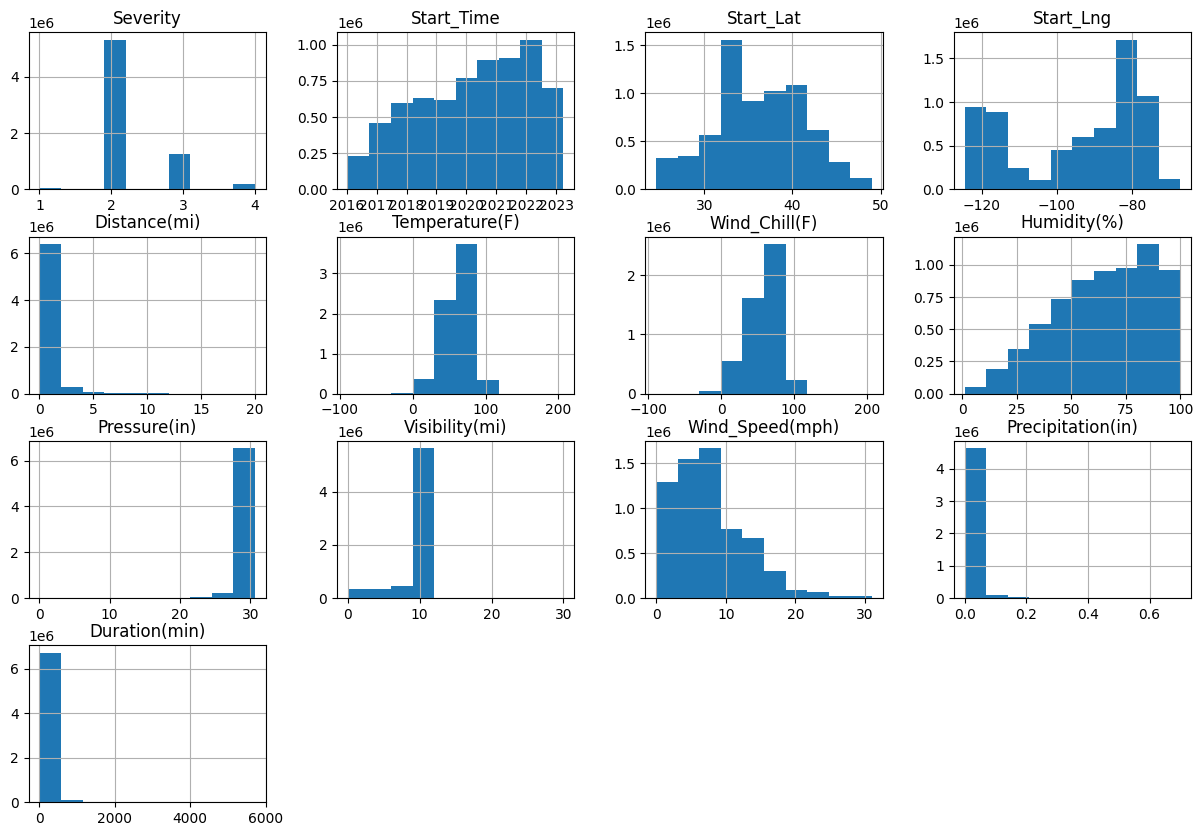

In [26]:
df_basic_clean.hist(figsize=(15, 10))

In [27]:
skewed(df_basic_clean)

[SKEWED]     Severity                       skew = +1.642  →  highly skewed right (positive)
[NORMAL]     Start_Lat                      skew = -0.056  →  approximately symmetric
[NORMAL]     Start_Lng                      skew = -0.481  →  approximately symmetric
[SKEWED]     Distance(mi)                   skew = +6.849  →  highly skewed right (positive)
[MODERATE]   Temperature(F)                 skew = -0.506  →  moderately skewed left (negative)
[MODERATE]   Wind_Chill(F)                  skew = -0.649  →  moderately skewed left (negative)
[NORMAL]     Humidity(%)                    skew = -0.405  →  approximately symmetric
[SKEWED]     Pressure(in)                   skew = -3.816  →  highly skewed left (negative)
[SKEWED]     Visibility(mi)                 skew = -1.185  →  highly skewed left (negative)
[MODERATE]   Wind_Speed(mph)                skew = +0.731  →  moderately skewed right (positive)
[SKEWED]     Precipitation(in)              skew = +10.106  →  highly skewed right 

#### Export to CSV

In [28]:
print(f"Number of rows: {df_basic_clean.shape[0]:,} rows")

df_basic_clean.to_csv("../data/processed/01.1/accidents_basic_clean.csv", index=False)

Number of rows: 6,836,365 rows


In [29]:
def skewed(df):
    feature_cols = df.columns
    for col in feature_cols:
        if df[col].dtype in ["int64", "float64"]:
            skew = df[col].skew()
            direction = "right (positive)" if skew > 0 else "left (negative)"
            if abs(skew) > 1:
                print(f"[SKEWED]     {col:<30} skew = {skew:+.3f}  →  highly skewed {direction}")
            elif abs(skew) > 0.5:
                print(f"[MODERATE]   {col:<30} skew = {skew:+.3f}  →  moderately skewed {direction}")
            else:
                print(f"[NORMAL]     {col:<30} skew = {skew:+.3f}  →  approximately symmetric")

skewed(df_basic_clean)

[SKEWED]     Severity                       skew = +1.642  →  highly skewed right (positive)
[NORMAL]     Start_Lat                      skew = -0.056  →  approximately symmetric
[NORMAL]     Start_Lng                      skew = -0.481  →  approximately symmetric
[SKEWED]     Distance(mi)                   skew = +6.849  →  highly skewed right (positive)
[MODERATE]   Temperature(F)                 skew = -0.506  →  moderately skewed left (negative)
[MODERATE]   Wind_Chill(F)                  skew = -0.649  →  moderately skewed left (negative)
[NORMAL]     Humidity(%)                    skew = -0.405  →  approximately symmetric
[SKEWED]     Pressure(in)                   skew = -3.816  →  highly skewed left (negative)
[SKEWED]     Visibility(mi)                 skew = -1.185  →  highly skewed left (negative)
[MODERATE]   Wind_Speed(mph)                skew = +0.731  →  moderately skewed right (positive)
[SKEWED]     Precipitation(in)              skew = +10.106  →  highly skewed right 